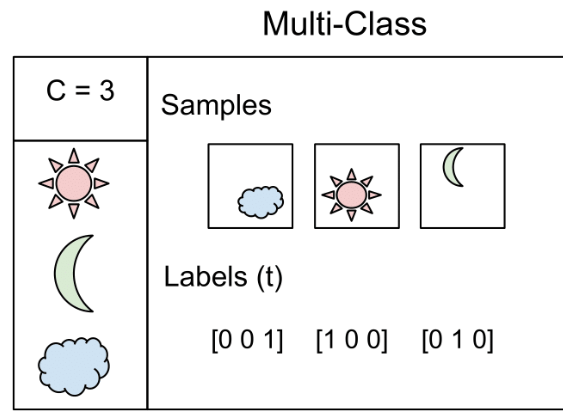

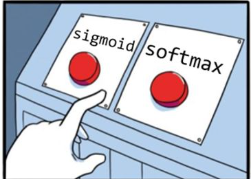

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

In [2]:
from keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train.shape, X_test.shape

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


((60000, 28, 28), (10000, 28, 28))

In [3]:
X_train[0].shape

(28, 28)

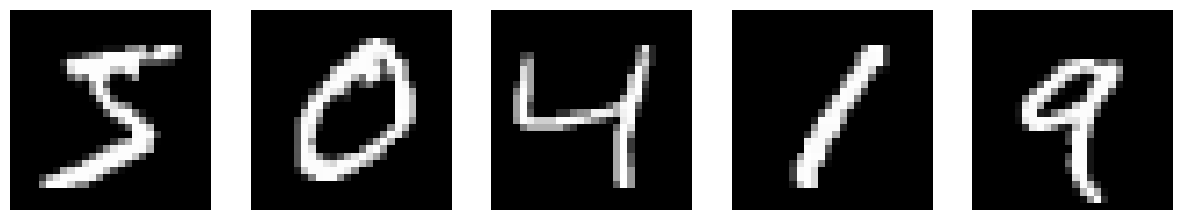

In [4]:
fig, ax = plt.subplots(1, 5, figsize=(15, 10))

for i in range(5):
    ax[i].imshow(X_train[i], cmap='gray')
    ax[i].axis('off')

In [5]:
y_train[:5]

array([5, 0, 4, 1, 9], dtype=uint8)

In the previous videos, we simplified the task and used only two classes for training to make the task a binary classification problem.

Now, let's take all 10 classes.

In [6]:
np.unique(y_train)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [7]:
print(X_train.min(), X_train.max())

X_train = X_train / 255.0
X_test = X_test / 255.0

print(X_train.min(), X_train.max())

0 255
0.0 1.0


You also need to modify the class label, which is currently labeled 0 or 1, and convert it to binary form.

This gives us two columns, where the first column indicates whether the image is class 0, and the second column indicates whether the image is class 1.

In [8]:
from keras.utils import to_categorical

y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

y_train[:5]

array([5, 0, 4, 1, 9], dtype=uint8)

In [9]:
y_train_cat[:5]

array([[0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]])

First, a 28x28 image is fed into the input, and we need to do something with it, since our grid cannot yet work with two-dimensional input. Here, the Flatten layer from Keras will help us, which stretches the image into a single vector. The image was 6x6, and it will become a vector with a dimension of 784.

There can only be one class in the image; it is not possible for there to be both 9 and 3 in the image, there is either 9 or 3. Therefore, using the sigmoid activation function at the output is not an option. Now let's see why.

#Sigmoid

In [15]:
X_train.shape[1:]

(28, 28)

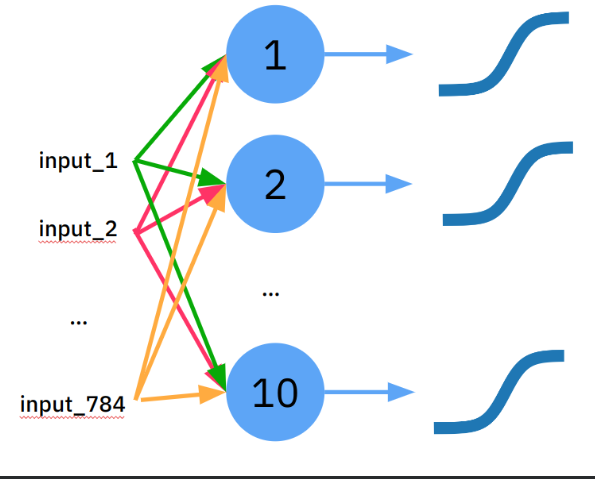

Let's compile the network. The loss function is categorical_crossentropy, not binary_crossentropy, because there are more than two classes.

In [13]:
from keras.models import Model
from keras.layers import Flatten, Dense
from keras.layers import Input

tf.random.set_seed(9)

input = Input(shape=(X_train.shape[1:]))
flatten = Flatten()(input)
output = Dense(10, activation='sigmoid')(flatten)

model = Model(inputs=input, outputs=output)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model.compile(
    optimizer='sgd',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [18]:
model.fit(
    X_train, y_train_cat,
    epochs=5,
    validation_data=(X_test, y_test_cat)
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.7179 - loss: 1.1383 - val_accuracy: 0.8843 - val_loss: 0.4776
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8766 - loss: 0.4768 - val_accuracy: 0.8970 - val_loss: 0.3986
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8890 - loss: 0.4124 - val_accuracy: 0.9030 - val_loss: 0.3661
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8961 - loss: 0.3824 - val_accuracy: 0.9067 - val_loss: 0.3475
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9005 - loss: 0.3639 - val_accuracy: 0.9102 - val_loss: 0.3351


In [19]:
probas = model.predict(X_test[:1])
probas

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


array([[0.45119333, 0.00328375, 0.5350194 , 0.9007605 , 0.15393268,
        0.3010048 , 0.01031817, 0.9997487 , 0.45870745, 0.92063266]],
      dtype=float32)

We can see that there are several high probabilities; most likely, the object is either class 9 or class 7.

The sigmoid activation function can vary from 0 to 1 for each neuron.

#Softmax

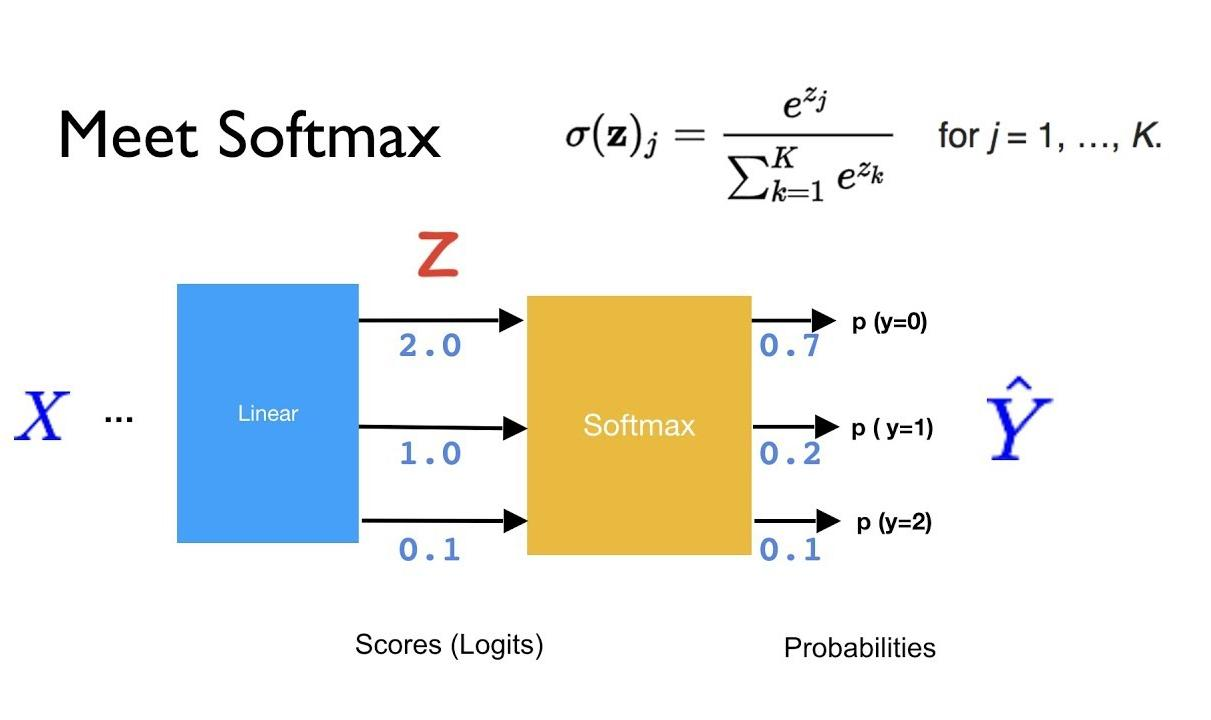

In [21]:
from sklearn.metrics import accuracy_score
from keras.layers import Softmax

In [22]:
tf.random.set_seed(9)

input = Input(shape=(X_train.shape[1:]))
flatten = Flatten()(input)
dense = Dense(10)(flatten)
output = Softmax()(dense)

model = Model(inputs=input, outputs=output)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 28, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         7,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax (Softmax)               │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
from keras import losses
model.compile(
    optimizer='sgd',
    loss=losses.CategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

model.fit(
    X_train, y_train_cat,
    epochs=5,
    validation_data=(X_test, y_test_cat)
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.7307 - loss: 1.1071 - val_accuracy: 0.8795 - val_loss: 0.4798
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8752 - loss: 0.4767 - val_accuracy: 0.8955 - val_loss: 0.4004
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8892 - loss: 0.4121 - val_accuracy: 0.9021 - val_loss: 0.3677
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8942 - loss: 0.3819 - val_accuracy: 0.9063 - val_loss: 0.3489
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8985 - loss: 0.3635 - val_accuracy: 0.9081 - val_loss: 0.3364


In [28]:
import numpy as np
np.set_printoptions(suppress=True)



In [29]:
logits = model.predict(X_test[:1])
logits

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


array([[0.00028412, 0.00000152, 0.0002302 , 0.00191036, 0.00006486,
        0.00013861, 0.00000328, 0.9937925 , 0.00016033, 0.00341424]],
      dtype=float32)

In [30]:
(np.exp(logits) / np.sum(np.exp(logits))).sum()

np.float32(1.0)

In [32]:
preds = model.predict(X_test)
preds.shape

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 854us/step


(10000, 10)

And we take the class label where the maximum probability is

In [33]:
preds_cls = preds.argmax(axis=1)
preds_cls

array([7, 2, 1, ..., 4, 5, 6])

In [34]:
from sklearn.metrics import accuracy_score

print(f'test acc: {accuracy_score(y_test, preds_cls)*100:.2f}% ({(y_test == preds_cls).sum()} out of {y_test.shape[0]})')

test acc: 90.81% (9081 out of 10000)


In [35]:
def plot_image(preds, true_label, img):
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])

    plt.imshow(img, cmap='gray')

    predicted_label = np.argmax(preds)
    if predicted_label == true_label:
        color = 'green'
    else:
        color = 'red'

    plt.xlabel(f"{predicted_label}\n" \
               f"{100*np.max(preds):2.0f}% " \
               f"({true_label})",
               color=color)

def plot_value_array(preds, true_label):
    plt.grid(False)
    plt.xticks(range(10))
    plt.yticks([])
    thisplot = plt.bar(range(10), preds, color="#777777")
    plt.ylim([0, 1])
    predicted_label = np.argmax(preds)

    thisplot[predicted_label].set_color('red')
    thisplot[true_label].set_color('green')

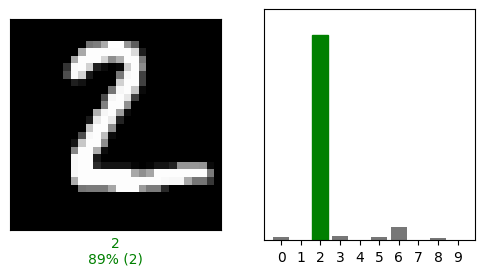

In [37]:
i = 1
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plot_image(preds[i], y_test[i], X_test[i])
plt.subplot(1,2,2)
plot_value_array(preds[i], y_test[i])
plt.show()

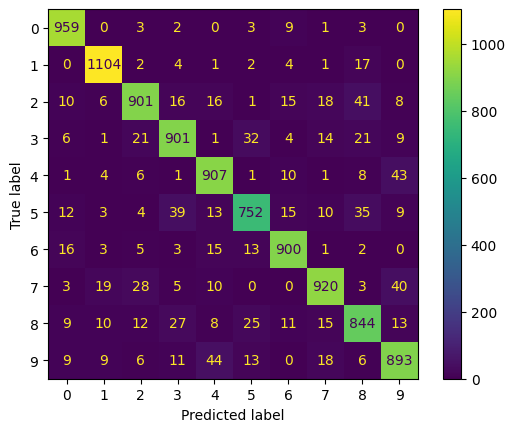

In [38]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, preds_cls, labels=np.arange(10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(10))
disp.plot();